# 🏏 IPL Data Analysis using Deliveries Dataset

This project explores IPL ball-by-ball data to extract meaningful insights such as:
- Team performance
- Batting strength (runs, fours, sixes)
- Bowling strength (wickets)
- Overall team comparison dashboard

In [127]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set(style='whitegrid')

In [128]:
matches=pd.read_csv('deliveries.csv')
matches

,match_id,inning,batting_team,bowling_team,over,ball,batter,bowler,non_striker,batsman_runs,extra_runs,total_runs,extras_type,is_wicket,player_dismissed,dismissal_kind,fielder
0,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,1,SC Ganguly,P Kumar,BB McCullum,0,1,1,legbyes,0,NaN,NaN,NaN
1,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,2,BB McCullum,P Kumar,SC Ganguly,0,0,0,NaN,0,NaN,NaN,NaN
2,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,3,BB McCullum,P Kumar,SC Ganguly,0,1,1,wides,0,NaN,NaN,NaN
3,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,4,BB McCullum,P Kumar,SC Ganguly,0,0,0,NaN,0,NaN,NaN,NaN
4,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,5,BB McCullum,P Kumar,SC Ganguly,0,0,0,NaN,0,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
260915,1426312,2,Kolkata Knight Riders,Sunrisers Hyderabad,9,5,SS Iyer,AK Markram,VR Iyer,1,0,1,NaN,0,NaN,NaN,NaN
260916,1426312,2,Kolkata Knight Riders,Sunrisers Hyderabad,9,6,VR Iyer,AK Markram,SS Iyer,1,0,1,NaN,0,NaN,NaN,NaN
260917,1426312,2,Kolkata Knight Riders,Sunrisers Hyderabad,10,1,VR Iyer,Shahbaz Ahmed,SS Iyer,1,0,1,NaN,0,NaN,NaN,NaN
260918,1426312,2,Kolkata Knight Riders,Sunrisers Hyderabad,10,2,SS Iyer,Shahbaz Ahmed,VR Iyer,1,0,1,NaN,0,NaN,NaN,NaN


In [129]:
# Lets take first look of dataset
matches.head()

,match_id,inning,batting_team,bowling_team,over,ball,batter,bowler,non_striker,batsman_runs,extra_runs,total_runs,extras_type,is_wicket,player_dismissed,dismissal_kind,fielder
0,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,1,SC Ganguly,P Kumar,BB McCullum,0,1,1,legbyes,0,NaN,NaN,NaN
1,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,2,BB McCullum,P Kumar,SC Ganguly,0,0,0,NaN,0,NaN,NaN,NaN
2,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,3,BB McCullum,P Kumar,SC Ganguly,0,1,1,wides,0,NaN,NaN,NaN
3,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,4,BB McCullum,P Kumar,SC Ganguly,0,0,0,NaN,0,NaN,NaN,NaN
4,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,5,BB McCullum,P Kumar,SC Ganguly,0,0,0,NaN,0,NaN,NaN,NaN


In [130]:
# Dataset information
matches.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 260920 entries, 0 to 260919
Data columns (total 17 columns):
 #   Column            Non-Null Count   Dtype 
---  ------            --------------   ----- 
 0   match_id          260920 non-null  int64 
 1   inning            260920 non-null  int64 
 2   batting_team      260920 non-null  object
 3   bowling_team      260920 non-null  object
 4   over              260920 non-null  int64 
 5   ball              260920 non-null  int64 
 6   batter            260920 non-null  object
 7   bowler            260920 non-null  object
 8   non_striker       260920 non-null  object
 9   batsman_runs      260920 non-null  int64 
 10  extra_runs        260920 non-null  int64 
 11  total_runs        260920 non-null  int64 
 12  extras_type       14125 non-null   object
 13  is_wicket         260920 non-null  int64 
 14  player_dismissed  12950 non-null   object
 15  dismissal_kind    12950 non-null   object
 16  fielder           9354 non-null    obj

In [131]:
# Lets take statstical information about dataset
matches.describe()

,match_id,inning,over,ball,batsman_runs,extra_runs,total_runs,is_wicket
count,2.609200e+05,260920.000000,260920.000000,260920.000000,260920.000000,260920.000000,260920.000000,260920.000000
mean,9.070665e+05,1.483531,9.197677,3.624486,1.265001,0.067806,1.332807,0.049632
std,3.679913e+05,0.502643,5.683484,1.814920,1.639298,0.343265,1.626416,0.217184
min,3.359820e+05,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,5.483340e+05,1.000000,4.000000,2.000000,0.000000,0.000000,0.000000,0.000000
50%,9.809670e+05,1.000000,9.000000,4.000000,1.000000,0.000000,1.000000,0.000000
75%,1.254066e+06,2.000000,14.000000,5.000000,1.000000,0.000000,1.000000,0.000000
max,1.426312e+06,6.000000,19.000000,11.000000,6.000000,7.000000,7.000000,1.000000


In [132]:
# lets chech how many rows and column dataset contains.
matches.shape  # (260920, 17) there are 260920 rows and 17 column

(260920, 17)

In [133]:
# Lets chech null values
matches.isnull().sum()

match_id                 0
inning                   0
batting_team             0
bowling_team             0
over                     0
ball                     0
batter                   0
bowler                   0
non_striker              0
batsman_runs             0
extra_runs               0
total_runs               0
extras_type         246795
is_wicket                0
player_dismissed    247970
dismissal_kind      247970
fielder             251566
dtype: int64

In [134]:
# Lets fill null values in essential column.
matches['extras_type']=matches['extras_type'].fillna('No extra')

In [135]:
# Lets find Which batsman made the highest runs.
matches.groupby('batter')['batsman_runs'].sum()

batter
A Ashish Reddy     280
A Badoni           634
A Chandila           4
A Chopra            53
A Choudhary         25
                  ... 
Yashpal Singh       47
Younis Khan          3
Yudhvir Singh       22
Yuvraj Singh      2754
Z Khan             117
Name: batsman_runs, Length: 673, dtype: int64

In [136]:
# Lets sort runs.
top_batsman=matches.groupby('batter')['batsman_runs'].sum()

top_batsman=top_batsman.sort_values(ascending=False)

top_batsman

batter
V Kohli         8014
S Dhawan        6769
RG Sharma       6630
DA Warner       6567
SK Raina        5536
                ... 
S Ladda            0
S Lamichhane       0
Abdur Razzak       0
SS Cottrell        0
KM Asif            0
Name: batsman_runs, Length: 673, dtype: int64

In [137]:
# top 10 batsman
best_batsman= top_batsman.head(10)

best_batsman

batter
V Kohli           8014
S Dhawan          6769
RG Sharma         6630
DA Warner         6567
SK Raina          5536
MS Dhoni          5243
AB de Villiers    5181
CH Gayle          4997
RV Uthappa        4954
KD Karthik        4843
Name: batsman_runs, dtype: int64

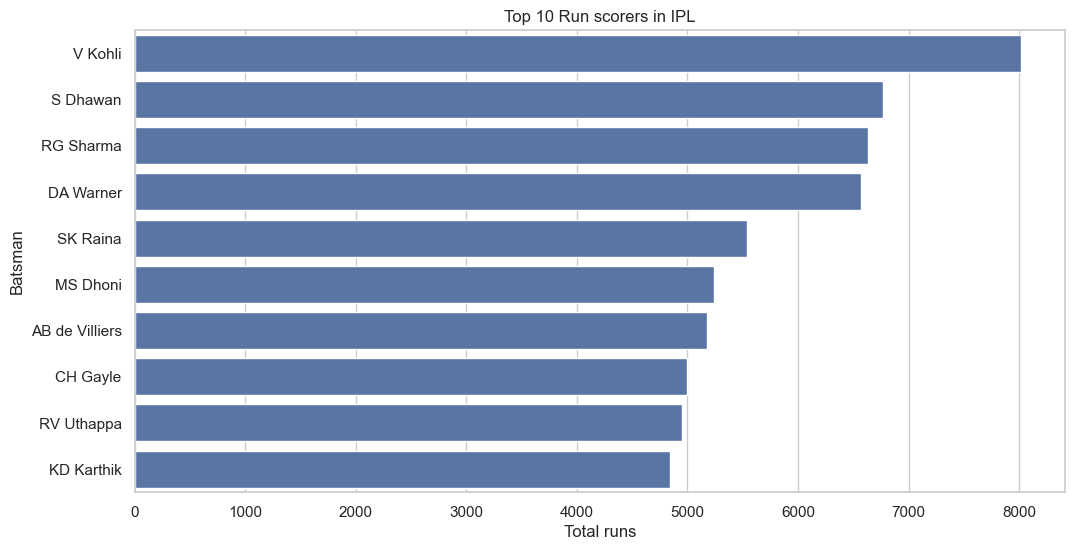

In [138]:
# Visualization
plt.figure(figsize=(12,6))

sns.barplot(
    x=best_batsman.values,
    y=best_batsman.index
)

plt.title('Top 10 Run scorers in IPL')

plt.xlabel('Total runs')
plt.ylabel('Batsman')

plt.show()

### Insight:
Top batsman consistently contributed high run totals across multiple IPL seasons.

In [139]:
# Lets check who hitted the most sixes.
sixes=matches[matches['batsman_runs']==6]

top_six_hitters=sixes['batter'].value_counts().head(10)

top_six_hitters

batter
CH Gayle          359
RG Sharma         281
V Kohli           273
AB de Villiers    253
MS Dhoni          252
DA Warner         236
KA Pollard        224
AD Russell        209
SV Samson         206
SK Raina          204
Name: count, dtype: int64

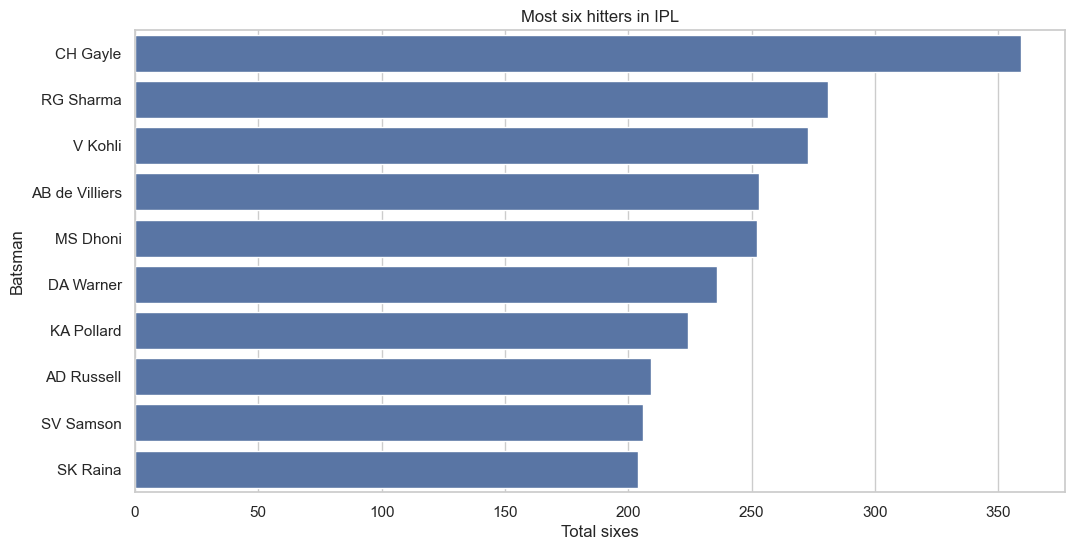

In [140]:
# Lets visualize 
plt.figure(figsize=(12,6))

sns.barplot(
    x=top_six_hitters.values,
    y=top_six_hitters.index
)

plt.xlabel('Total sixes')
plt.ylabel('Batsman')

plt.title('Most six hitters in IPL')

plt.show()


### Insight:
This are players who hitted most sixes in Ipl history among all players.

In [141]:
# Top 10 fours hitter.
fours=matches[matches['batsman_runs']==4]

top_4_hitters=fours['batter'].value_counts().head(10)

top_4_hitters

batter
S Dhawan        768
V Kohli         708
DA Warner       663
RG Sharma       599
SK Raina        506
G Gambhir       492
RV Uthappa      481
AM Rahane       479
KD Karthik      466
F du Plessis    422
Name: count, dtype: int64

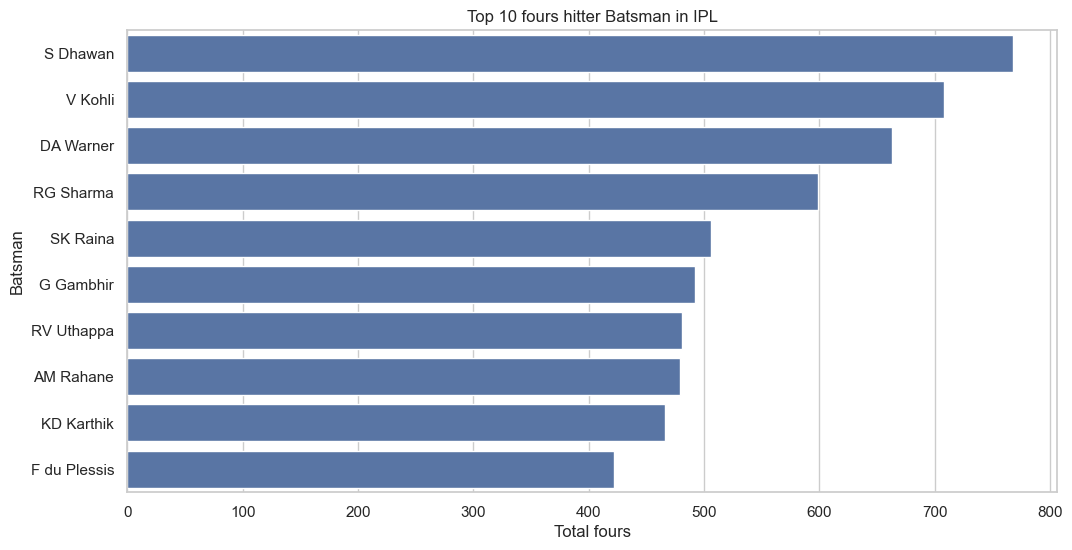

In [142]:
# lets visualize
plt.figure(figsize=(12,6))

sns.barplot(
    x=top_4_hitters.values,
    y=top_4_hitters.index
)

plt.title('Top 10 fours hitter Batsman in IPL')

plt.xlabel('Total fours')
plt.ylabel('Batsman')

plt.show()


### Insight:
This all are players who hitted most of fours in ipl history among all.

In [143]:
# Lets find Which bowler has the highest wickest in ipl.
matches.groupby('bowler')['is_wicket'].sum()

top_bowlers=matches.groupby('bowler')['is_wicket'].sum()

top_bowlers=top_bowlers.sort_values(ascending=False)
top_bowlers

best_bowlers=top_bowlers.head(10)
best_bowlers

bowler
YS Chahal     213
DJ Bravo      207
PP Chawla     201
SP Narine     200
R Ashwin      198
B Kumar       195
SL Malinga    188
A Mishra      183
JJ Bumrah     182
RA Jadeja     169
Name: is_wicket, dtype: int64

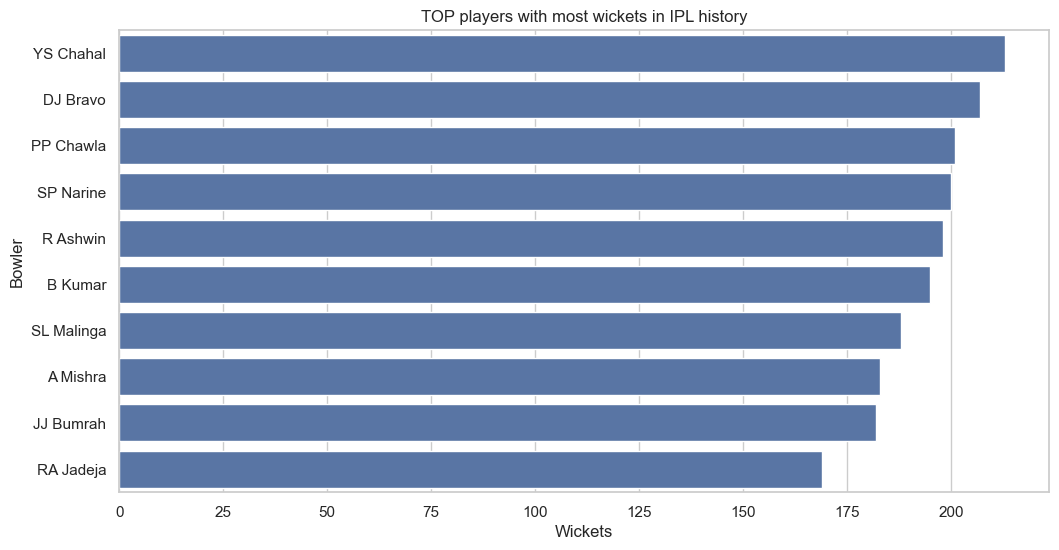

In [144]:
# Lets visualize
plt.figure(figsize=(12,6))

sns.barplot(
    x=best_bowlers.values,
    y=best_bowlers.index
)
plt.title('TOP players with most wickets in IPL history')
plt.xlabel('Wickets')
plt.ylabel('Bowler')

plt.show()

### Insight:
This Players had highest wickets among all bowlers in IPL History.

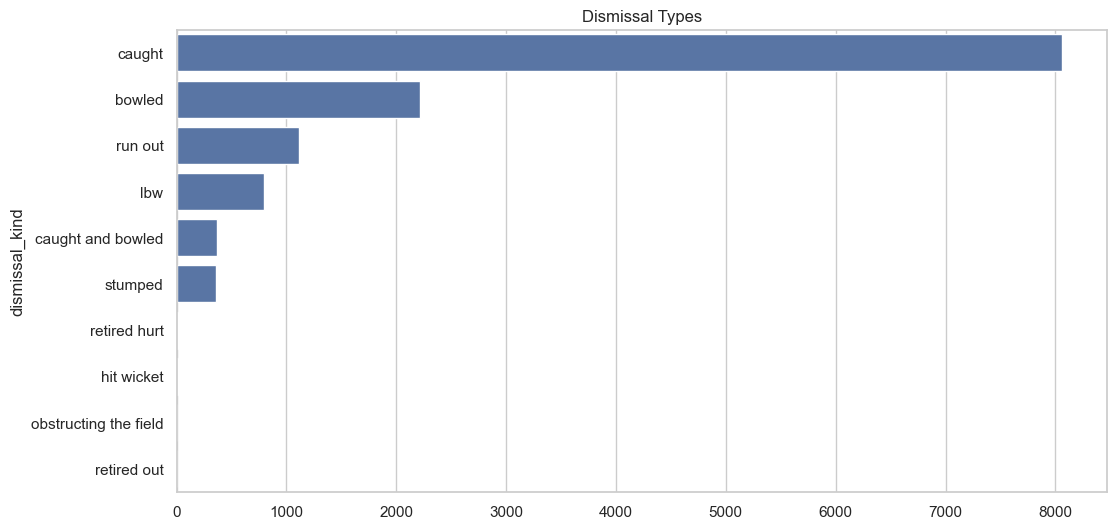

In [145]:
# Lets find Dismissal Type.
dismissal= matches['dismissal_kind'].value_counts()

plt.figure(figsize=(12,6))
sns.barplot(
    x=dismissal.values,
    y=dismissal.index
)

plt.title('Dismissal Types')
plt.show()

# Insight:
Dominance of Catches: being caught is the most dominant mode of dismissal by a massive margin,
this indicates the high risk ,high-reward approach of modern T20 batting where mistimed shots easily find fielders.

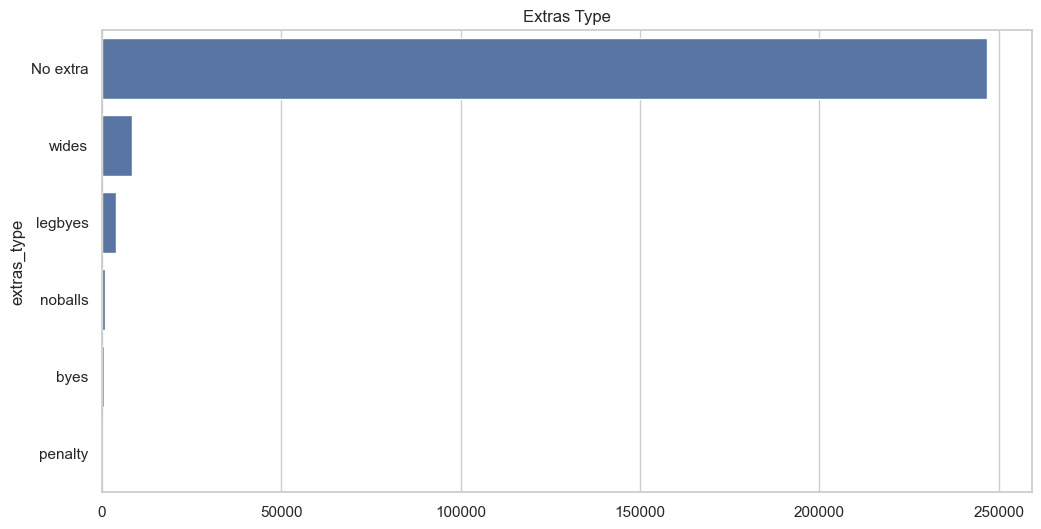

In [146]:
# Extras analysis
extra=matches['extras_type'].value_counts()

plt.figure(figsize=(12,6))

sns.barplot(
    x=extra.values,
    y=extra.index
)

plt.title('Extras Type')
plt.show()

### Insight:
The vast majority of deliveries in the IPL result in 'No extra ' highlighting the incrdibly high discipline and skill level of word-class bowlers.
among the actual extras conceded , wides are by far the most frequent offense , as bowlers constantly push the balll outside the guideline to stay out of
batsman's hitting arc.

In [147]:
team_runs=matches.groupby('batting_team')['total_runs'].sum().reset_index()
team_runs=matches.groupby('batting_team')['total_runs'].sum().sort_values(ascending=False)
team_runs

batting_team
Mumbai Indians                 42176
Kolkata Knight Riders          39331
Chennai Super Kings            38629
Royal Challengers Bangalore    37692
Rajasthan Royals               34747
Kings XI Punjab                30064
Sunrisers Hyderabad            29071
Delhi Daredevils               24296
Delhi Capitals                 14900
Deccan Chargers                11463
Punjab Kings                    9536
Gujarat Titans                  7757
Lucknow Super Giants            7510
Pune Warriors                   6358
Gujarat Lions                   4862
Royal Challengers Bengaluru     2930
Rising Pune Supergiant          2470
Rising Pune Supergiants         2063
Kochi Tuskers Kerala            1901
Name: total_runs, dtype: int64

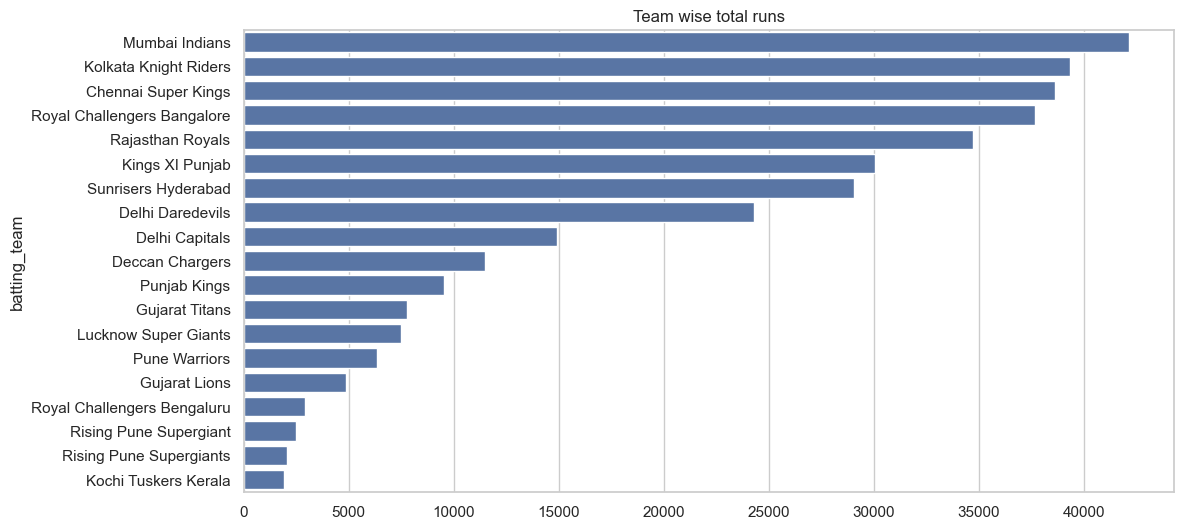

In [148]:
plt.figure(figsize=(12,6))

sns.barplot(
    x=team_runs.values,
    y=team_runs.index
)
plt.title('Team wise total runs')
plt.style.use('ggplot')
plt.show()

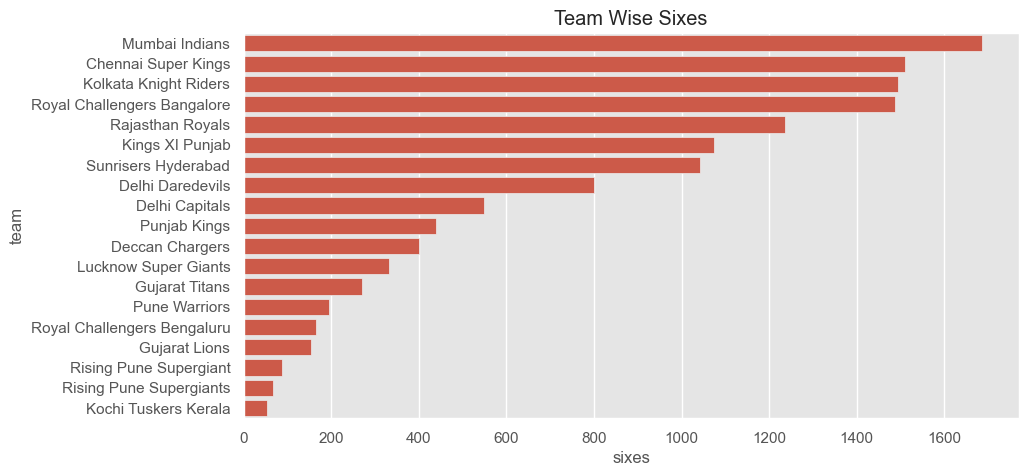

In [149]:
# Lets take team wise six.
sixes = matches[matches['batsman_runs'] == 6]
team_sixes = sixes['batting_team'].value_counts().reset_index()
team_sixes.columns = ['team', 'sixes']

plt.figure(figsize=(10,5))
sns.barplot(x='sixes', y='team', data=team_sixes)
plt.title("Team Wise Sixes")
plt.show()

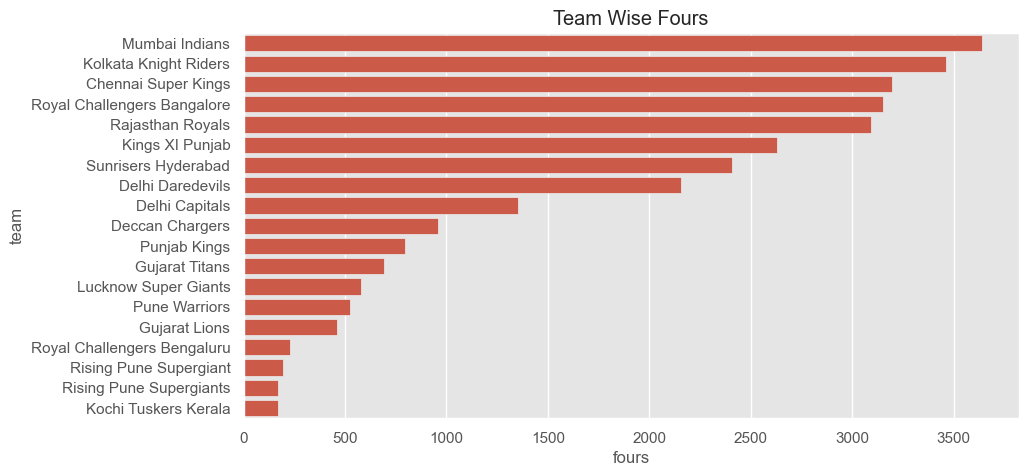

In [150]:
# Lets take team wise most four.
fours = matches[matches['batsman_runs'] == 4]
team_fours = fours['batting_team'].value_counts().reset_index()
team_fours.columns = ['team', 'fours']

plt.figure(figsize=(10,5))
sns.barplot(x='fours', y='team', data=team_fours)
plt.title("Team Wise Fours")
plt.show()

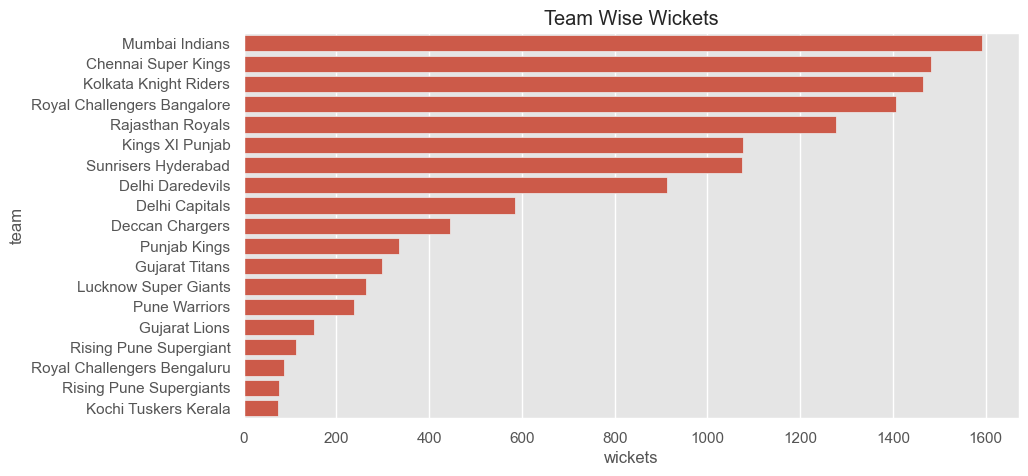

In [151]:
# Lets take team wise most wickets.
wickets = matches.dropna(subset=['player_dismissed'])
team_wickets = wickets['bowling_team'].value_counts().reset_index()
team_wickets.columns = ['team', 'wickets']

plt.figure(figsize=(10,5))
sns.barplot(x='wickets', y='team', data=team_wickets)
plt.title("Team Wise Wickets")
plt.show()

# This is all over final dashboard.

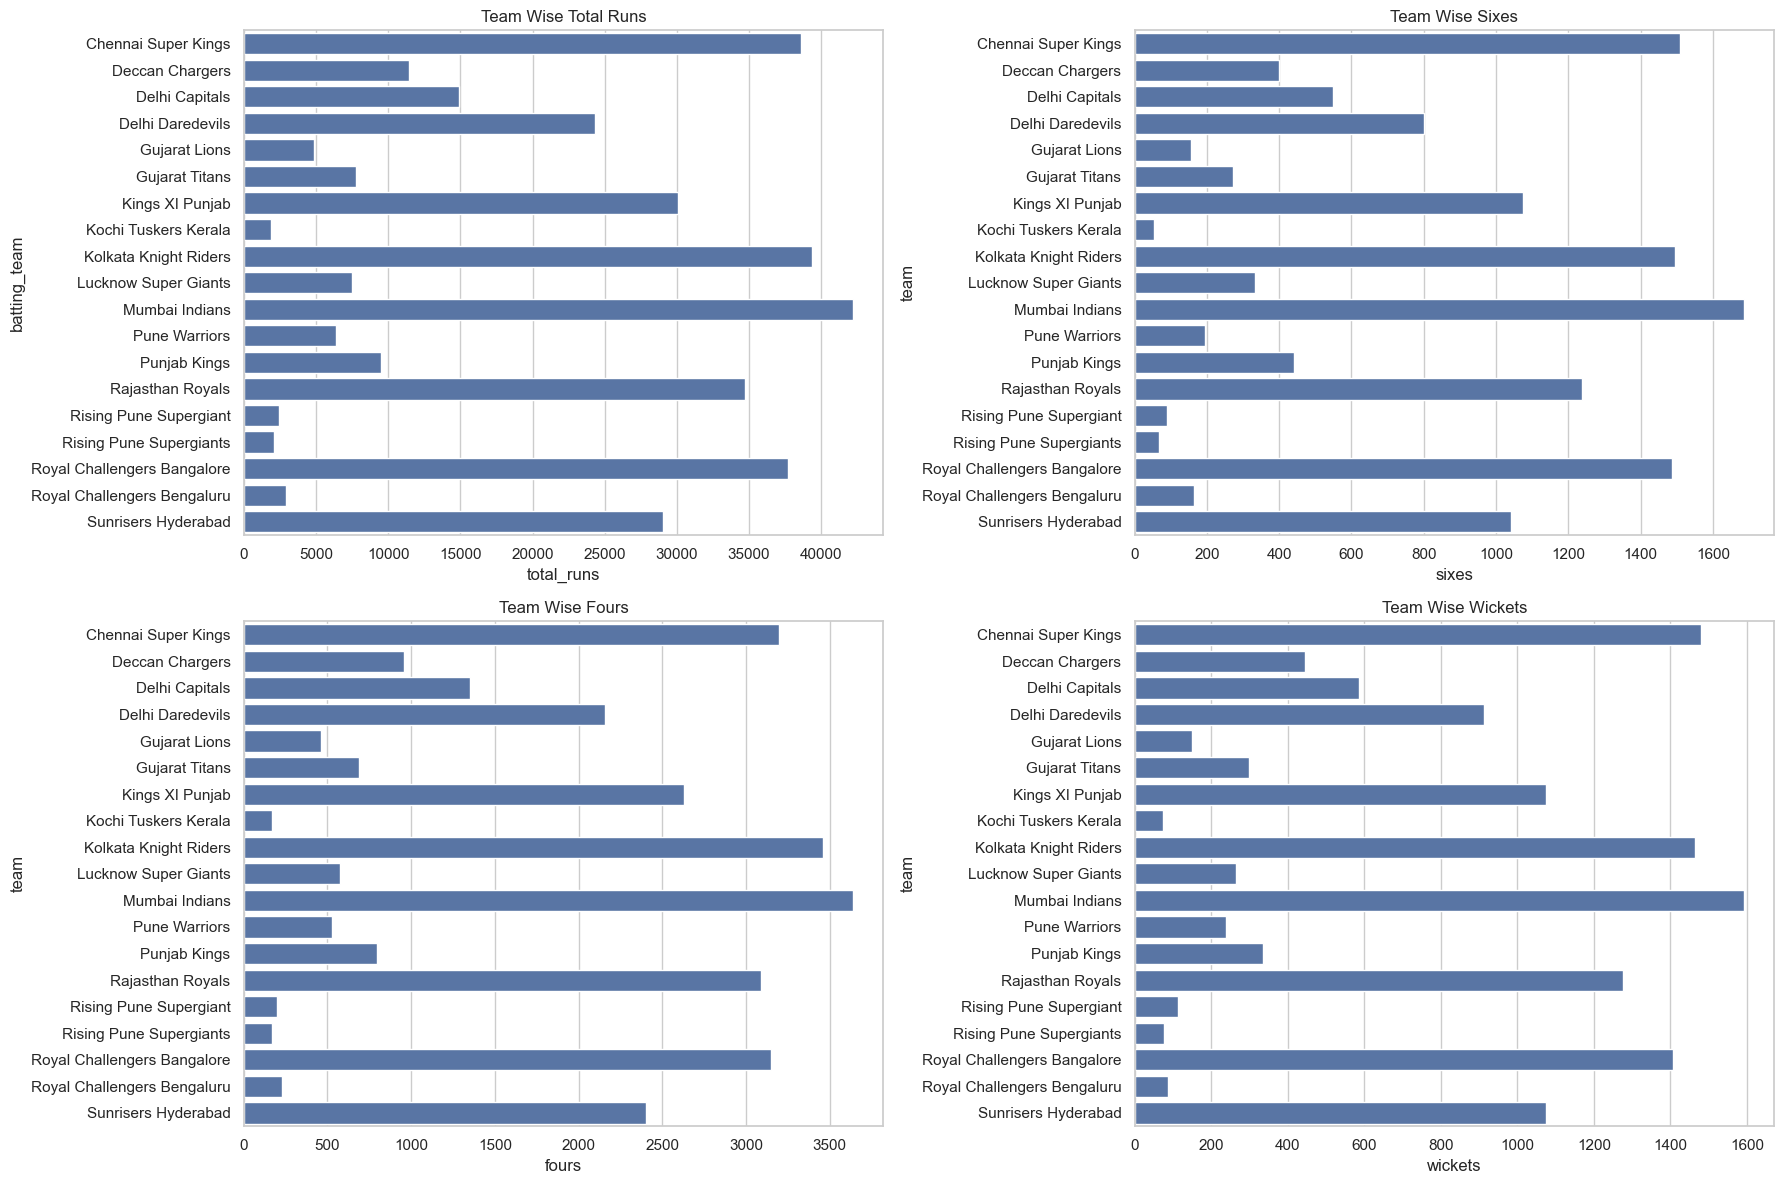

In [152]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("deliveries.csv")

sns.set(style="whitegrid")

# -----------------------------
# Team Runs
# -----------------------------
team_runs = df.groupby('batting_team')['total_runs'].sum().reset_index()

# -----------------------------
# Team Sixes
# -----------------------------
team_sixes = df[df['batsman_runs'] == 6]
team_sixes = team_sixes.groupby('batting_team')['batsman_runs'].count().reset_index()
team_sixes.columns = ['team', 'sixes']

# -----------------------------
# Team Fours
# -----------------------------
team_fours = df[df['batsman_runs'] == 4]
team_fours = team_fours.groupby('batting_team')['batsman_runs'].count().reset_index()
team_fours.columns = ['team', 'fours']

# -----------------------------
# Team Wickets
# -----------------------------
wickets = df[df['player_dismissed'].notna()]
team_wickets = wickets.groupby('bowling_team')['player_dismissed'].count().reset_index()
team_wickets.columns = ['team', 'wickets']

# =============================
# DASHBOARD
# =============================
fig, axes = plt.subplots(2, 2, figsize=(18, 12))

# Total Runs
sns.barplot(
    x=team_runs['total_runs'],
    y=team_runs['batting_team'],
    ax=axes[0,0]
)
axes[0,0].set_title("Team Wise Total Runs")

# Sixes
sns.barplot(
    x=team_sixes['sixes'],
    y=team_sixes['team'],
    ax=axes[0,1]
)
axes[0,1].set_title("Team Wise Sixes")

# Fours
sns.barplot(
    x=team_fours['fours'],
    y=team_fours['team'],
    ax=axes[1,0]
)
axes[1,0].set_title("Team Wise Fours")

# Wickets
sns.barplot(
    x=team_wickets['wickets'],
    y=team_wickets['team'],
    ax=axes[1,1]
)
axes[1,1].set_title("Team Wise Wickets")

plt.tight_layout()
plt.show()

## 🏆 Conclusion

This analysis provides insights into IPL team performances based on:
- Batting strength (runs, fours, sixes)
- Bowling strength (wickets)

The dashboard helps compare teams visually and understand overall performance trends in IPL.